# Notebook 01 – Exploratory Data Analysis

Load the DBLP co-authorship graph, verify the power-law degree distribution and small-world property, and inspect connected components.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from graph_utils import load_graph, basic_stats, print_stats

EDGE_FILE = os.path.join('..', 'data', 'com-dblp.ungraph.txt')
COMM_FILE = os.path.join('..', 'data', 'com-dblp.top5000.cmty.txt')

## 1. Load Graph

In [2]:
G, communities = load_graph(EDGE_FILE, COMM_FILE)
print(f'Nodes: {G.number_of_nodes():,}   Edges: {G.number_of_edges():,}')
print(f'Ground-truth communities loaded: {len(communities) if communities else 0}')

Nodes: 317,080   Edges: 1,049,866
Ground-truth communities loaded: 5000


## 2. Basic Statistics

In [3]:
stats = basic_stats(G)
print_stats(stats)

Nodes              : 317,080
Edges              : 1,049,866
Average degree     : 6.6221
Density            : 2.09e-05
Connected          : True
# Components       : 1
Largest CC fraction: 1.0000
Avg clustering     : 0.6324
Transitivity       : 0.3064
Diameter (LCC)     : 18
Avg path len (LCC) : 6.1075


## 3. Degree Distribution – Power-Law Check

Hill estimator (k=200): γ ≈ 5.949


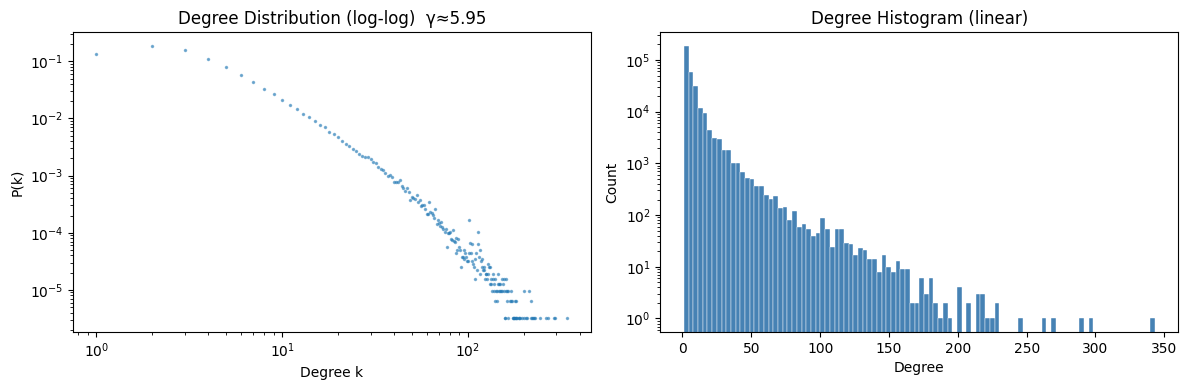

In [4]:
from centrality import hill_estimator

degrees = [d for _, d in G.degree()]
deg_count = Counter(degrees)
ks = np.array(sorted(deg_count))
ps = np.array([deg_count[k] for k in ks])
ps = ps / ps.sum()

gamma = hill_estimator(degrees, k=200)
print(f'Hill estimator (k=200): γ ≈ {gamma:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(ks, ps, '.', alpha=0.5, markersize=3)
axes[0].set_xlabel('Degree k')
axes[0].set_ylabel('P(k)')
axes[0].set_title(f'Degree Distribution (log-log)  γ≈{gamma:.2f}')

axes[1].hist(degrees, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Count')
axes[1].set_title('Degree Histogram (linear)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'degree_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Connected Components

In [5]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f'Number of components: {len(components)}')
print(f'Largest CC: {len(components[0]):,} nodes ({100*len(components[0])/G.number_of_nodes():.1f}%)')
print(f'2nd largest: {len(components[1]):,} nodes' if len(components) > 1 else 'Only one component')
component_sizes = [len(c) for c in components]
print(f'\nSize distribution of smaller components:')
small = [s for s in component_sizes[1:] if s > 1]
if small:
    print(f'  min={min(small)}, max={max(small)}, median={np.median(small):.0f}')

Number of components: 1
Largest CC: 317,080 nodes (100.0%)
Only one component

Size distribution of smaller components:


## 5. Small-World Check

In [6]:
print('Small-world indicators:')
print(f'  Avg clustering coefficient : {stats["avg_clustering"]:.4f}')
print(f'  Avg path length (LCC)       : {stats["avg_path_length_lcc"]:.4f}')
print(f'  Diameter (LCC)              : {stats["diameter_lcc"]}')
print()
# For a random Erdos-Renyi graph with same n,m:
n, m = stats['n'], stats['m']
p_er = 2*m / (n*(n-1))
er_clust = p_er
import math
er_path = math.log(n) / math.log(n * p_er) if n * p_er > 1 else float('inf')
print(f'  Expected ER clustering      : {er_clust:.6f}')
print(f'  Expected ER path length     : {er_path:.4f}')
print(f'  Clustering ratio C/C_er     : {stats["avg_clustering"]/er_clust:.1f}x  (>>1 confirms small-world)')

Small-world indicators:
  Avg clustering coefficient : 0.6324
  Avg path length (LCC)       : 6.1075
  Diameter (LCC)              : 18

  Expected ER clustering      : 0.000021
  Expected ER path length     : 6.7006
  Clustering ratio C/C_er     : 30282.1x  (>>1 confirms small-world)
